<a href="https://colab.research.google.com/github/Swaraj-Palai/Linear_Regression_Model-_Diabetes_Dataset/blob/main/Tute_Dude_Food_Delivery_Time_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Collection and Exploratory Data Analysis (EDA)**

## **Data Import and Preprocessing**

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Load the dataset (Food_Delivery_Time_Prediction.csv).**

In [70]:
df = pd.read_csv("/content/sample_data/Food_Delivery_Time_Prediction.csv")
df

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,ORD0196,"(17.910045, 81.56199)","(18.098924, 87.896124)",23.82,Cloudy,High,8,Medium,Night,Bike,4.7,4.0,50.39,1432.26,66.34
196,ORD0197,"(21.66459, 82.226635)","(16.892341, 80.554716)",6.09,Snowy,Medium,8,Low,Night,Bicycle,3.0,3.6,90.54,1720.25,40.27
197,ORD0198,"(14.575401, 82.55641)","(13.625369, 82.418092)",20.61,Snowy,High,4,Medium,Afternoon,Bike,2.9,3.4,73.20,1356.58,5.10
198,ORD0199,"(12.094497, 82.893369)","(19.135509, 86.659978)",24.06,Rainy,High,9,Low,Night,Car,3.9,4.8,53.94,354.39,85.25


**Handle Missing Values**

In [71]:
df.isnull().sum()

,0
Order_ID,0
Customer_Location,0
Restaurant_Location,0
Distance,0
Weather_Conditions,0
Traffic_Conditions,0
Delivery_Person_Experience,0
Order_Priority,0
Order_Time,0
Vehicle_Type,0


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

In [73]:
df[df.duplicated(subset=['Order_ID'])]

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount


In [74]:
df[df['Delivery_Time'] < 0]

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount


In [75]:
df[(df['Restaurant_Rating'] < 1) |
   (df['Restaurant_Rating'] > 5)]

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount


In [76]:
for i in df.columns:
  if df[i].nunique() < 85:
    print(df[i].value_counts())
    print(50*"---")

Weather_Conditions
Rainy     57
Sunny     53
Snowy     48
Cloudy    42
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------
Traffic_Conditions
Low       81
Medium    68
High      51
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------
Delivery_Person_Experience
8     28
2     27
5     25
7     24
3     22
6     19
1     19
9     14
4     11
10    11
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------
Order_Priority
Low       75
Medium    67
High      58
Name: count, dtype: int64
-----------------------------------------------------------------------------------------------------------------------------------------------

In [77]:
# Customer_Location
df[['Customer_Lat','Customer_Lon']] = df['Customer_Location'].str.strip("()").str.split(",",expand=True).astype(float)
# Restaurant_Location
df[['Restaurant_Lat','Restaurant_Lon']] = df['Restaurant_Location'].str.strip("()").str.split(",",expand=True).astype(float)
# Customer_Location AND Restaurant_Location
df.drop(['Customer_Location','Restaurant_Location','Order_ID'],axis=1,inplace=True)

**Data Transformation**

In [78]:
df['Rush_Condition'] = (
    (df['Traffic_Conditions'] == 'High') |
    (df['Weather_Conditions'].isin(['Rainy','Snowy']))
).astype(int)

***# OrdinalEncoder***

In [79]:
from sklearn.preprocessing import OrdinalEncoder as OE
oe = OE(categories=[['Low','Medium','High']])
df[['Order_Priority']] = oe.fit_transform(df[['Order_Priority']])
oe = OE(categories=[['High','Medium','Low']])
df[['Traffic_Conditions']] = oe.fit_transform(df[['Traffic_Conditions']])

***# One_Hot_Encoder***

In [80]:
from sklearn.preprocessing import OneHotEncoder as OHE

categorical_cols = ["Weather_Conditions","Vehicle_Type","Order_Time"]

encoder = OHE(sparse_output=False,handle_unknown="ignore")

encoded = encoder.fit_transform(df[categorical_cols])

encoded_df = pd.DataFrame(encoded,columns=encoder.get_feature_names_out(categorical_cols),index=df.index)

df = pd.concat([df.drop(columns=categorical_cols), encoded_df],axis=1)

**Normalize/Standardize Numeric Columns**

***# StandardScaler***

In [81]:
# from sklearn.preprocessing import StandardScaler as SS

# ss = SS()

# numeric_cols = [
#     'Distance',
#     'Delivery_Person_Experience',
#     'Restaurant_Rating',
#     'Customer_Rating',
#     'Order_Cost',
#     'Tip_Amount',
#     'Delivery_Time'
# ]

# df[numeric_cols] = ss.fit_transform(df[numeric_cols])

# **Exploratory Data Analysis (EDA)**

**Descriptive Statistics**

In [82]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

stats = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Mode': df[num_cols].mode().iloc[0],
    'Variance': df[num_cols].var(),
    'Std_Dev': df[num_cols].std()
})

print(stats)

                                   Mean       Median         Mode  \
Distance                      11.498050    10.265000     1.320000   
Traffic_Conditions             1.150000     1.000000     2.000000   
Delivery_Person_Experience     5.250000     5.000000     8.000000   
Order_Priority                 0.915000     1.000000     0.000000   
Restaurant_Rating              3.738500     3.800000     3.800000   
Customer_Rating                3.686500     3.700000     2.600000   
Delivery_Time                 70.494950    72.775000    66.840000   
Order_Cost                  1046.488700  1035.950000  1813.250000   
Tip_Amount                    46.616650    47.530000     2.220000   
Customer_Lat                  16.997762    17.081582    12.021992   
Customer_Lon                  82.478466    82.271895    77.018445   
Restaurant_Lat                16.675150    16.516376    12.019922   
Restaurant_Lon                82.579902    82.482346    77.010580   
Rush_Condition                 0.6

**Correlation Analysis**

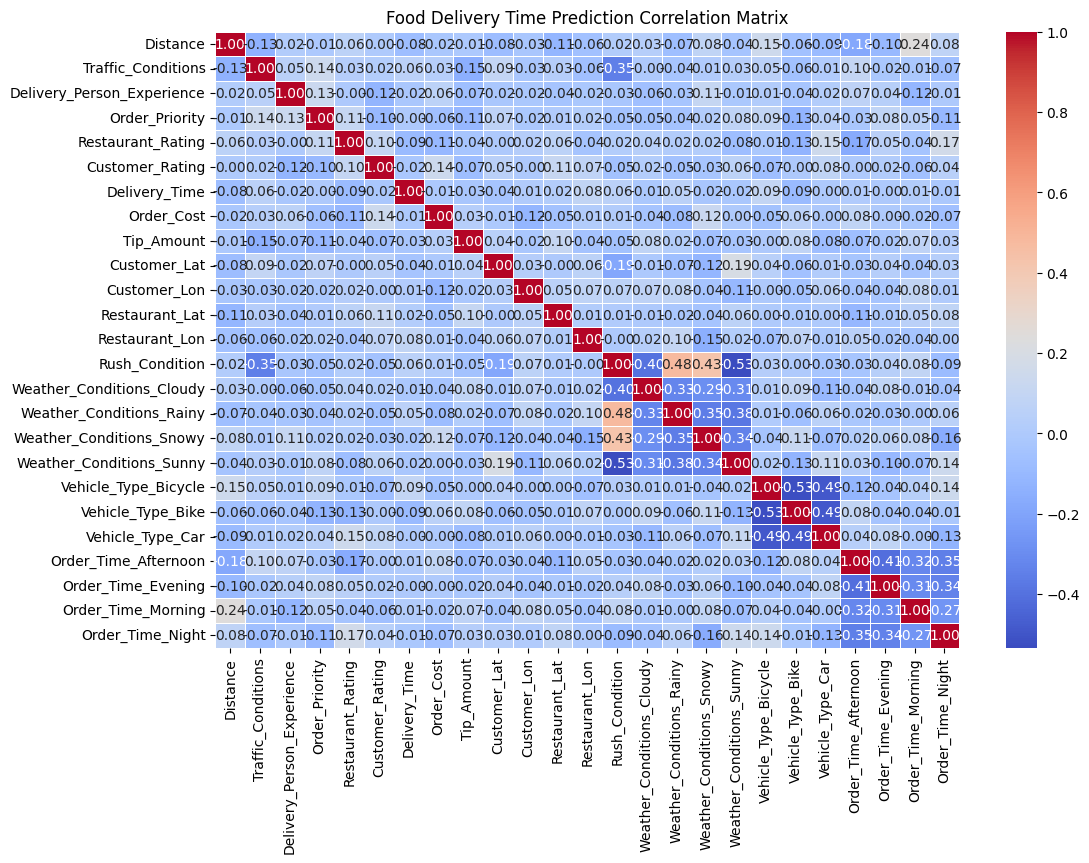

In [83]:
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt=".2f",linewidths=0.5)
plt.title("Food Delivery Time Prediction Correlation Matrix")
plt.show()

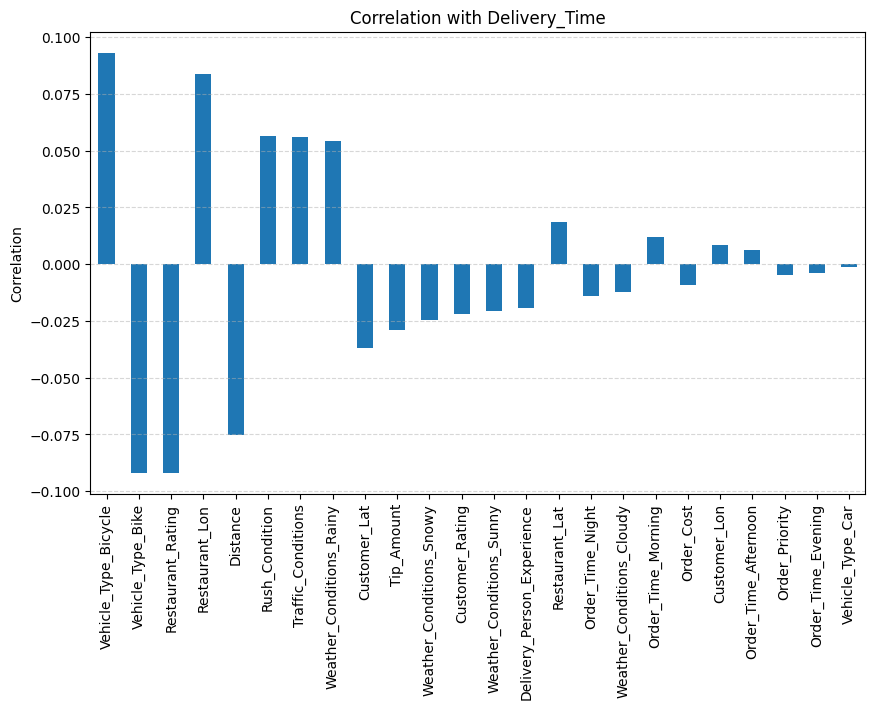

Vehicle_Type_Bicycle          0.093194
Vehicle_Type_Bike            -0.091859
Restaurant_Rating            -0.091855
Restaurant_Lon                0.083964
Distance                     -0.075143
Rush_Condition                0.056438
Traffic_Conditions            0.055840
Weather_Conditions_Rainy      0.054402
Customer_Lat                 -0.037146
Tip_Amount                   -0.029154
Weather_Conditions_Snowy     -0.024621
Customer_Rating              -0.021952
Weather_Conditions_Sunny     -0.020492
Delivery_Person_Experience   -0.019098
Restaurant_Lat                0.018548
Order_Time_Night             -0.013972
Weather_Conditions_Cloudy    -0.012272
Order_Time_Morning            0.011984
Order_Cost                   -0.009307
Customer_Lon                  0.008253
Order_Time_Afternoon          0.006363
Order_Priority               -0.004982
Order_Time_Evening           -0.004021
Vehicle_Type_Car             -0.001372
Name: Delivery_Time, dtype: float64


In [84]:
import matplotlib.pyplot as plt

corr = (
    df.corr(numeric_only=True)['Delivery_Time']
      .drop('Delivery_Time')
      .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(10,6))
corr.plot(kind='bar')

plt.title('Correlation with Delivery_Time')
plt.ylabel('Correlation')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

print(corr)

**Outlier Detection**

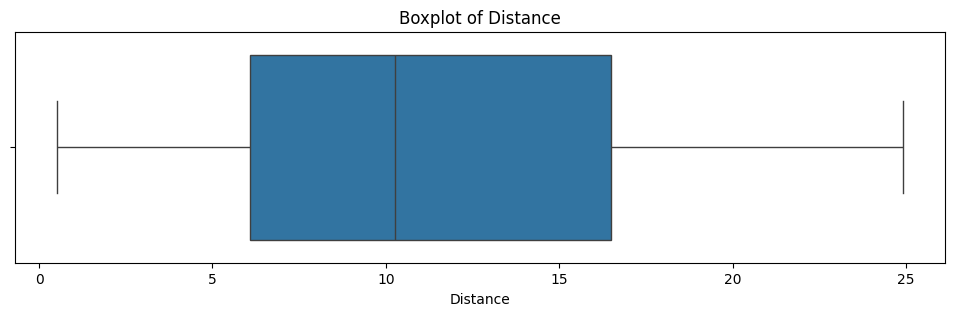

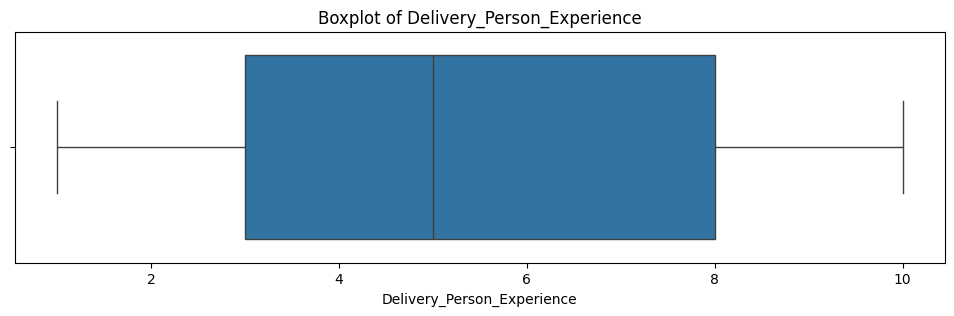

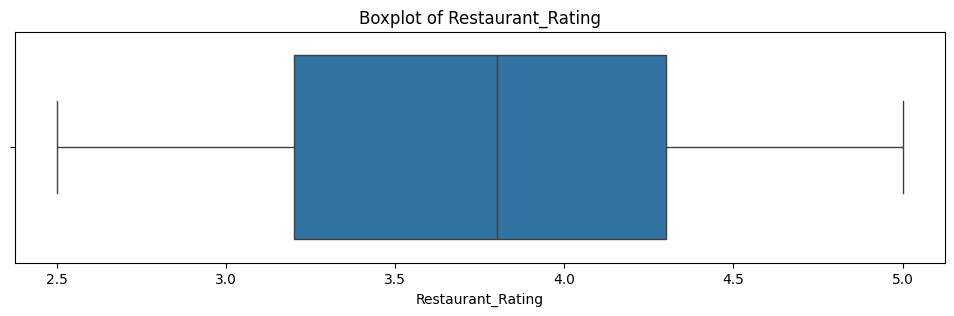

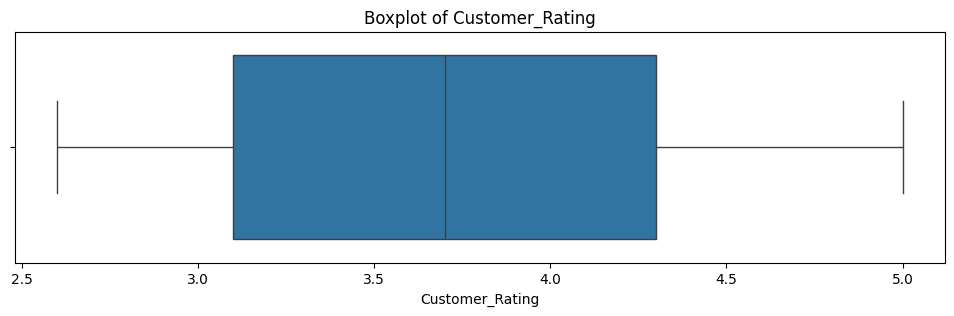

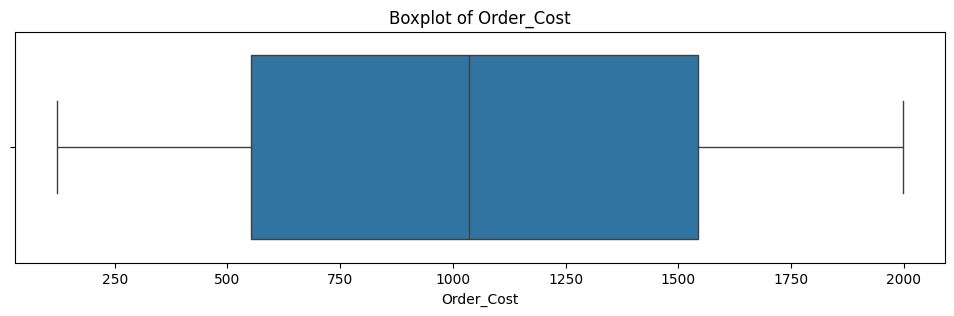

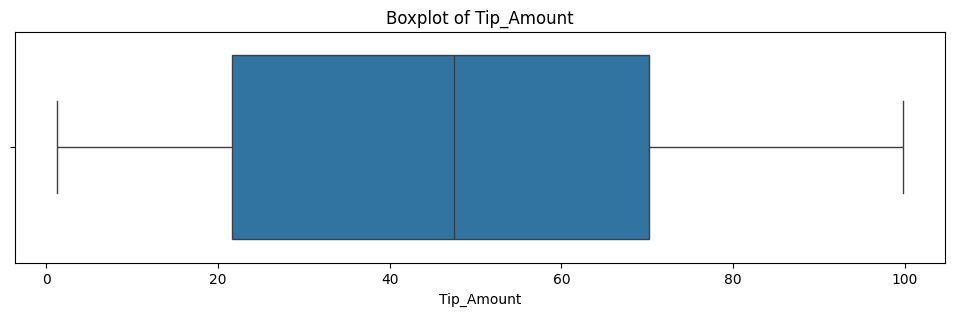

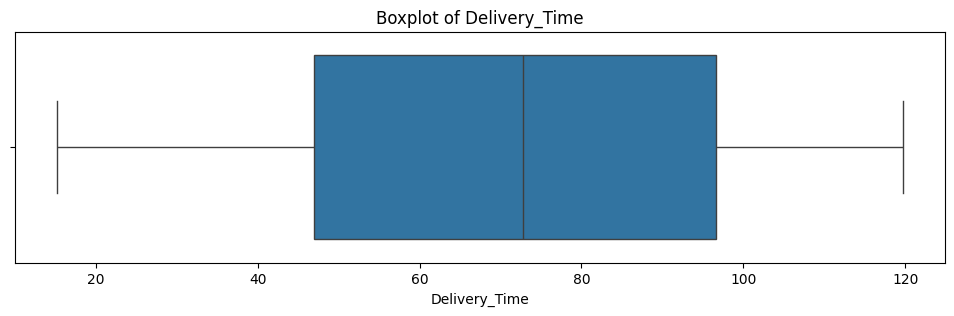

In [85]:
num_cols = [
    'Distance',
    'Delivery_Person_Experience',
    'Restaurant_Rating',
    'Customer_Rating',
    'Order_Cost',
    'Tip_Amount',
    'Delivery_Time'
]

for col in num_cols:
    plt.figure(figsize=(12,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# **Predictive Modeling**

### **Linear Regression Model**

In [86]:
from sklearn.linear_model import LinearRegression as LR
from sklearn.preprocessing import StandardScaler as SS
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split as TTS
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score as r2

In [87]:
x=df[["Distance","Traffic_Conditions","Order_Priority"]]
y=df["Delivery_Time"]

preprocessor = ColumnTransformer([("num", SS(), ["Distance","Traffic_Conditions","Order_Priority"])])

pipe = Pipeline([("preprocessor", preprocessor),("model", LR())])

x_train,x_test,y_train,y_test = TTS(x,y,test_size=0.2,random_state=42)

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)


print("MAE :", mae(y_test, y_pred))

print("MSE :", mse(y_test, y_pred))

print("RMSE :",rmse(y_test, y_pred))

print("R2 Score :", r2(y_test, y_pred))

MAE : 25.481142482650487
MSE : 916.284286339676
RMSE : 30.270188079027125
R2 Score : 0.00930587620468204


In [88]:
fd = pd.DataFrame()
fd['Rush_Condition'] = 1 - df['Rush_Condition']
col =['Delivery_Time','Distance']
cole =['Delivery_Person_Experience','Order_Priority','Tip_Amount']
colt = ['Vehicle_Type_Bicycle', 'Vehicle_Type_Bike', 'Vehicle_Type_Car',
       'Order_Time_Afternoon', 'Order_Time_Evening', 'Order_Time_Morning',
       'Order_Time_Night']

In [89]:
for i in col:
  fd[i] = (df[i] <= (df[i].median())).astype(int)

for i in cole:
  fd[i] = (df[i] >= (df[i].median())).astype(int)
for i in colt:
  fd[i] = df[i]

Accuracy: 0.5

Confusion Matrix:
[[ 7 13]
 [ 7 13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.35      0.41        20
           1       0.50      0.65      0.57        20

    accuracy                           0.50        40
   macro avg       0.50      0.50      0.49        40
weighted avg       0.50      0.50      0.49        40

                       Feature  Coefficient
1                     Distance    -0.539253
5         Vehicle_Type_Bicycle    -0.314900
0               Rush_Condition     0.313686
10          Order_Time_Morning    -0.302607
6            Vehicle_Type_Bike     0.235933
11            Order_Time_Night     0.200247
7             Vehicle_Type_Car     0.079506
3               Order_Priority     0.075360
4                   Tip_Amount    -0.061554
8         Order_Time_Afternoon     0.054670
9           Order_Time_Evening     0.048230
2   Delivery_Person_Experience    -0.042504


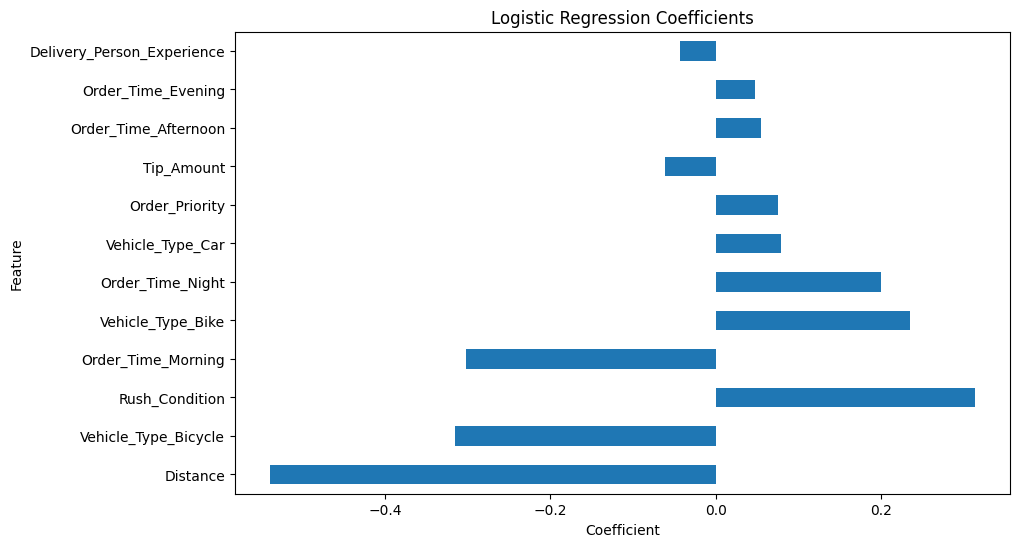

In [90]:
X = fd.drop(columns=['Delivery_Time'])



y = fd['Delivery_Time']





X_train, X_test, y_train, y_test = TTS(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)



from sklearn.linear_model import LogisticRegression



lr = LogisticRegression(

    max_iter=1000,

    random_state=42

)



lr.fit(X_train, y_train)



y_pred = lr.predict(X_test)



from sklearn.metrics import (

    accuracy_score,

    confusion_matrix,

    classification_report

)



print("Accuracy:",

      accuracy_score(y_test, y_pred))



print("\nConfusion Matrix:")

print(confusion_matrix(y_test, y_pred))



print("\nClassification Report:")

print(classification_report(y_test, y_pred))



import pandas as pd



coef_df = pd.DataFrame({

    'Feature': X.columns,

    'Coefficient': lr.coef_[0]

})



coef_df = coef_df.sort_values(

    by='Coefficient',

    key=abs,

    ascending=False

)



print(coef_df)





coef_df.set_index('Feature')['Coefficient'].plot(

    kind='barh',

    figsize=(10,6)

)



plt.title('Logistic Regression Coefficients')

plt.xlabel('Coefficient')

plt.show()

========== MODEL ACCURACY ==========
Linear Regression Accuracy   : 0.475
Logistic Regression Accuracy : 0.5

========== CONFUSION MATRICES ==========

Linear Regression:
[[ 2 19]
 [ 2 17]]

Logistic Regression:
[[ 7 13]
 [ 7 13]]


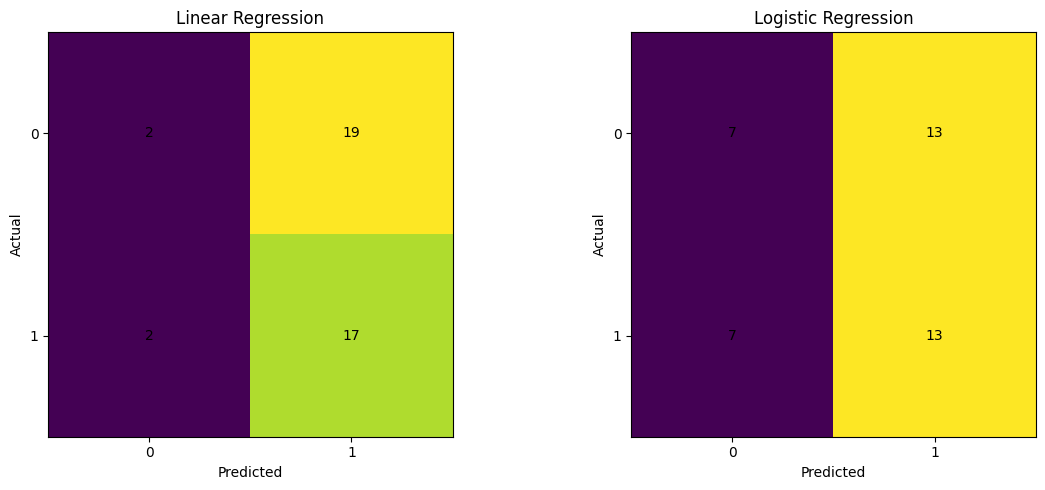


========== ROC-AUC ==========
Linear Regression ROC-AUC   : 0.576
Logistic Regression ROC-AUC : 0.404


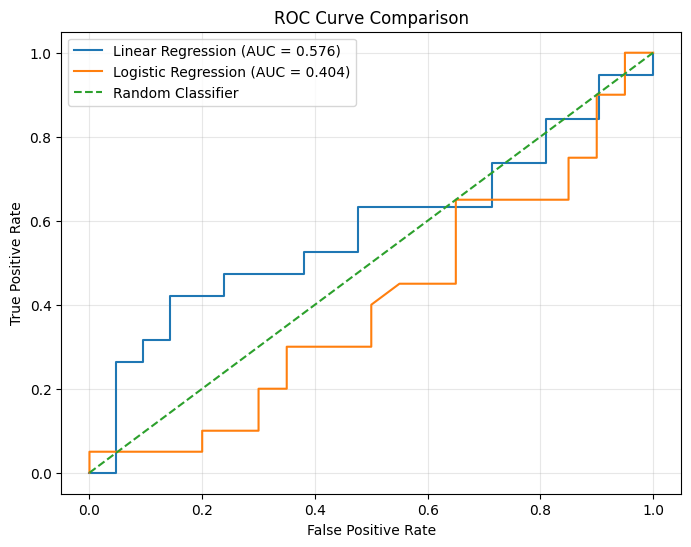


========== FINAL MODEL COMPARISON ==========
                 Model  Accuracy   ROC-AUC
0    Linear Regression     0.475  0.576441
1  Logistic Regression     0.500  0.403750


In [91]:
# ============================================================
# MODEL EVALUATION AND COMPARISON
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt
import pandas as pd


# ------------------------------------------------------------
# 1. Get ORIGINAL Linear Regression predictions again
# ------------------------------------------------------------

# x_test still contains the Linear Regression test data
# pipe is still your fitted Linear Regression pipeline

linear_pred_time = pipe.predict(x_test)

# Recover the actual continuous Delivery_Time values
linear_actual_time = df.loc[x_test.index, 'Delivery_Time']


# ------------------------------------------------------------
# 2. Convert Linear Regression into binary classes
# ------------------------------------------------------------

threshold = df['Delivery_Time'].median()

# 1 = Delivery time <= median
# 0 = Delivery time > median

linear_actual_class = (
    linear_actual_time <= threshold
).astype(int)

linear_pred_class = (
    linear_pred_time <= threshold
).astype(int)


# ------------------------------------------------------------
# 3. Logistic Regression predictions
# ------------------------------------------------------------

logistic_actual_class = y_test

logistic_pred_class = lr.predict(X_test)

logistic_prob = lr.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# 4. Accuracy
# ------------------------------------------------------------

linear_accuracy = accuracy_score(
    linear_actual_class,
    linear_pred_class
)

logistic_accuracy = accuracy_score(
    logistic_actual_class,
    logistic_pred_class
)

print("========== MODEL ACCURACY ==========")

print(
    "Linear Regression Accuracy   :",
    round(linear_accuracy, 3)
)

print(
    "Logistic Regression Accuracy :",
    round(logistic_accuracy, 3)
)


# ------------------------------------------------------------
# 5. Confusion Matrices
# ------------------------------------------------------------

linear_cm = confusion_matrix(
    linear_actual_class,
    linear_pred_class,
    labels=[0, 1]
)

logistic_cm = confusion_matrix(
    logistic_actual_class,
    logistic_pred_class,
    labels=[0, 1]
)

print("\n========== CONFUSION MATRICES ==========")

print("\nLinear Regression:")
print(linear_cm)

print("\nLogistic Regression:")
print(logistic_cm)


# ------------------------------------------------------------
# 6. Visualize Confusion Matrices
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Linear Regression
axes[0].imshow(linear_cm)

axes[0].set_title("Linear Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])

for i in range(2):
    for j in range(2):
        axes[0].text(
            j,
            i,
            linear_cm[i, j],
            ha="center",
            va="center"
        )


# Logistic Regression
axes[1].imshow(logistic_cm)

axes[1].set_title("Logistic Regression")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])

for i in range(2):
    for j in range(2):
        axes[1].text(
            j,
            i,
            logistic_cm[i, j],
            ha="center",
            va="center"
        )


plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. ROC Curve
# ------------------------------------------------------------

# Lower delivery time = class 1
# Therefore negative delivery time is used as the score

linear_score = -linear_pred_time


fpr_linear, tpr_linear, _ = roc_curve(
    linear_actual_class,
    linear_score
)

fpr_logistic, tpr_logistic, _ = roc_curve(
    logistic_actual_class,
    logistic_prob
)


# ------------------------------------------------------------
# 8. ROC-AUC
# ------------------------------------------------------------

linear_auc = roc_auc_score(
    linear_actual_class,
    linear_score
)

logistic_auc = roc_auc_score(
    logistic_actual_class,
    logistic_prob
)

print("\n========== ROC-AUC ==========")

print(
    "Linear Regression ROC-AUC   :",
    round(linear_auc, 3)
)

print(
    "Logistic Regression ROC-AUC :",
    round(logistic_auc, 3)
)


# ------------------------------------------------------------
# 9. ROC Curve Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_linear,
    tpr_linear,
    label=f"Linear Regression (AUC = {linear_auc:.3f})"
)

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ------------------------------------------------------------
# 10. Final Comparison
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Logistic Regression"
    ],

    "Accuracy": [
        linear_accuracy,
        logistic_accuracy
    ],

    "ROC-AUC": [
        linear_auc,
        logistic_auc
    ]
})

print("\n========== FINAL MODEL COMPARISON ==========")

print(comparison)

# Actionable Insights

Based on your Linear Regression and Logistic Regression results, you can write the following:

1. Optimize Delivery Routes
Distance was the strongest feature in your Logistic Regression model, with a coefficient of approximately -0.54.
This indicates that distance has a relatively stronger influence than the other selected features.
The company should optimize delivery routes to reduce unnecessary travel and improve delivery efficiency.
GPS-based route optimization can be used to select shorter and faster routes.
2. Adjust Staffing During High-Traffic Periods
Rush_Condition had a relatively high coefficient of approximately 0.31 in the Logistic Regression model.
This suggests that rush conditions may influence whether an order falls into the faster/slower delivery category.
More delivery personnel can be assigned during periods with heavy traffic or difficult weather conditions.
Additional riders can help reduce delivery delays during peak periods.
3. Improve Delivery Staff Training
Delivery_Person_Experience had a negative coefficient of approximately -0.043.
Although its effect is relatively small in your current model, experienced delivery personnel may have better route knowledge and handling skills.
Regular training can focus on route selection, traffic navigation, order handling, and efficient delivery practices.
4. Vehicle Optimization
The Logistic Regression coefficients show differences between Bicycle, Bike, and Car.
The company can assign vehicles according to distance, traffic conditions, and delivery location.
For example, bikes may be preferable in congested areas, while cars may be more suitable for longer-distance deliveries.
5. Improve Peak-Time Operations
Your dataset contains Order_Time categories such as Morning, Afternoon, Evening, and Night.
The model shows different effects for these time periods.
The company can analyze historical order volume and increase delivery capacity during periods where delays are more likely.
6. Overall Business Recommendation

Your models currently have limited predictive performance (Linear Regression R² ≈ 0.009 and Logistic Regression accuracy = 50%). Therefore, these recommendations should be treated as initial operational insights rather than strong causal conclusions.

For a stronger production model, collect additional variables such as:

Actual traffic duration
Route length/time
Number of orders currently pending
Number of available delivery personnel
Restaurant preparation time
Peak/off-peak indicator
Weather severity
Exact order timestamp
Delivery area/zone